# GestDeck - Cuaderno 01: Recopilación, Limpieza, EDA y Transformación del Dataset

Este cuaderno documenta todo el ciclo de vida inicial de los datos (ETL) para el proyecto académico **GestDeck**. El objetivo es procesar secuencias de video en bruto, analizarlas, extraer características topológicas usando MediaPipe, limpiar anomalías y preparar un dataset final enriquecido (aumentado) y debidamente particionado para el entrenamiento de una red neuronal profunda LSTM.

In [1]:
import os
import glob
import cv2
import numpy as np
import pandas as pd
import mediapipe as mp
import json
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.model_selection import train_test_split

# Configuraciones visuales
sns.set_theme(style="whitegrid")

# Variables Globales
RAW_DATA_DIR = "../dataset/raw_videos"
PROCESSED_DIR = "../dataset/processed" # Datos Crudos de MediaPipe
FINAL_DATA_DIR = "../dataset/final"    # Datos Listos para la LSTM

SEQUENCE_LENGTH = 15
FEATURES = 42

for d in [PROCESSED_DIR, FINAL_DATA_DIR]:
    os.makedirs(d, exist_ok=True)

## 1. Detalle de Fuentes de Datos y Análisis Exploratorio de Videos

**Fuente de Datos**: El dataset primario consta de grabaciones de video propias generadas específicamente para este proyecto. Las muestras han sido catalogadas en subcarpetas de acuerdo con la clase de gesto correspondiente.
**Volumen Total Esperado**: 9 clases × 20 videos = 180 muestras independientes.

In [2]:
classes = [d for d in os.listdir(RAW_DATA_DIR) if os.path.isdir(os.path.join(RAW_DATA_DIR, d))]
video_stats = []

for cls in classes:
    class_dir = os.path.join(RAW_DATA_DIR, cls)
    videos = glob.glob(os.path.join(class_dir, "*.mp4")) + glob.glob(os.path.join(class_dir, "*.avi"))

    for v_path in videos:
        cap = cv2.VideoCapture(v_path)
        try:
            width      = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
            height     = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
            fps        = cap.get(cv2.CAP_PROP_FPS)
            frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        finally:
            cap.release()

        duration = frame_count / fps if fps > 0 else 0
        video_stats.append({
            "Clase": cls,
            "Ruta": v_path,
            "Resolución": f"{width}x{height}",
            "FPS": round(fps, 2),
            "Frames_Totales": frame_count,
            "Duracion_Segundos": round(duration, 2)
        })

df_videos = pd.DataFrame(video_stats)
print(f"Volumen total de muestra: {len(df_videos)} videos encontrados.")
df_videos.head()


Volumen total de muestra: 529 videos encontrados.


,Clase,Ruta,Resolución,FPS,Frames_Totales,Duracion_Segundos
0,ANTERIOR,../dataset/raw_videos\ANTERIOR\VIDEO_ANTERIOR_...,640x360,15.18,35,2.31
1,ANTERIOR,../dataset/raw_videos\ANTERIOR\VIDEO_ANTERIOR_...,640x360,15.25,31,2.03
2,ANTERIOR,../dataset/raw_videos\ANTERIOR\VIDEO_ANTERIOR_...,640x360,15.19,36,2.37
3,ANTERIOR,../dataset/raw_videos\ANTERIOR\VIDEO_ANTERIOR_...,640x360,15.08,42,2.79
4,ANTERIOR,../dataset/raw_videos\ANTERIOR\VIDEO_ANTERIOR_...,640x360,15.11,45,2.98


C:\Users\Usuario\AppData\Local\Temp\ipykernel_8448\1246501402.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_videos, y='Clase', order=df_videos['Clase'].value_counts().index, palette='viridis')


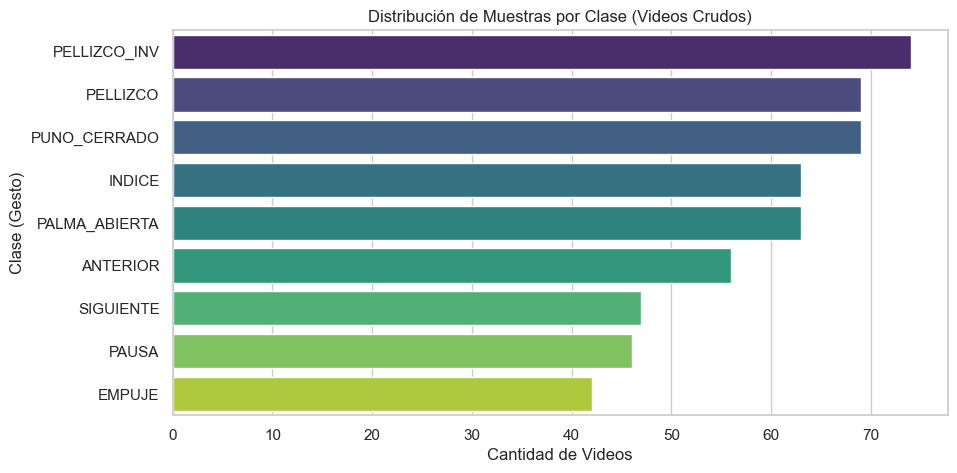


--- Estadísticas Descriptivas (Resoluciones y Duraciones) ---


,FPS,Frames_Totales,Duracion_Segundos
count,529.000000,529.000000,529.000000
mean,16.860397,40.956522,2.293951
std,3.720178,26.434596,0.893813
min,15.020000,11.000000,0.710000
25%,15.160000,26.000000,1.650000
50%,15.230000,31.000000,2.050000
75%,15.330000,41.000000,2.660000
max,29.990000,181.000000,7.240000


Resolución
1280x720    349
640x360     180
Name: count, dtype: int64

In [3]:
# Distribución de clases
plt.figure(figsize=(10, 5))
sns.countplot(data=df_videos, y='Clase', order=df_videos['Clase'].value_counts().index, palette='viridis')
plt.title('Distribución de Muestras por Clase (Videos Crudos)')
plt.xlabel('Cantidad de Videos')
plt.ylabel('Clase (Gesto)')
plt.show()

# Estadísticas descriptivas de las entradas crudas
print("\n--- Estadísticas Descriptivas (Resoluciones y Duraciones) ---")
display(df_videos.describe())
display(df_videos['Resolución'].value_counts())

In [ ]:
# Histograma de Resoluciones
plt.figure(figsize=(10, 5))
sns.countplot(data=df_videos, x='Resolución', order=df_videos['Resolución'].value_counts().index, palette='magma', hue='Resolución', legend=False)
plt.title('Distribución de Resoluciones de Video')
plt.xlabel('Resolución')
plt.ylabel('Cantidad de Videos')
plt.xticks(rotation=45)
plt.show()

## 2. Extracción de Características (MediaPipe Pipeline)

El procesamiento directo de matrices de píxeles (videos en bruto) hacia un modelo profundo requiere un volumen de datos masivo. Para abordar nuestra escasez de datos (180 videos), introducimos un **Feature Extractor preentrenado (MediaPipe)**.

**Justificación:** MediaPipe procesa cada frame y extrae las coordenadas `(x, y)` espaciales de 21 landmarks de la mano, omitiendo la textura, iluminación y fondo. Esto transforma nuestro tensor 4D `(muestras, frames, ancho, alto, canales)` en un tensor 3D numéricamente ligero `(muestras, frames=10, features=42)`.

In [23]:
import urllib.request
import os

# Cerrar detector anterior si existe para liberar recursos de CPU/GPU
try:
    detector.close()
except Exception:
    pass

model_path = "hand_landmarker.task"
if not os.path.exists(model_path):
    print("Descargando modelo HandLandmarker de MediaPipe...")
    url = "https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task"
    urllib.request.urlretrieve(url, model_path)
    print("Modelo descargado.")

from mediapipe.tasks import python
from mediapipe.tasks.python import vision

base_options = python.BaseOptions(model_asset_path=model_path)
options = vision.HandLandmarkerOptions(
    base_options=base_options,
    num_hands=1,
    min_hand_detection_confidence=0.3,
    min_hand_presence_confidence=0.3,
    min_tracking_confidence=0.3
)
detector = vision.HandLandmarker.create_from_options(options)

def extract_features(video_path):
    cap = cv2.VideoCapture(video_path)
    raw_detections = []
    frame_idx = 0
    try:
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame_rgb)
            results = detector.detect(mp_image)
            if results.hand_landmarks:
                features = []
                for lm in results.hand_landmarks[0]:
                    features.extend([lm.x, lm.y])
                raw_detections.append((frame_idx, np.array(features)))
            frame_idx += 1
    finally:
        cap.release()

    if len(raw_detections) < 2:
        return None

    detected_indices = np.array([f[0] for f in raw_detections])
    detected_vectors = np.array([f[1] for f in raw_detections])

    first, last = detected_indices[0], detected_indices[-1]
    all_indices = np.arange(first, last + 1)
    interpolated = np.zeros((len(all_indices), FEATURES))
    for dim in range(FEATURES):
        interpolated[:, dim] = np.interp(
            all_indices, detected_indices, detected_vectors[:, dim]
        )

    if len(interpolated) >= SEQUENCE_LENGTH:
        return interpolated[:SEQUENCE_LENGTH]
    else:
        pad = np.zeros((SEQUENCE_LENGTH - len(interpolated), FEATURES))
        return np.vstack([interpolated, pad])

# Contar total de videos para la barra de progreso
total_videos = sum(
    len(glob.glob(os.path.join(RAW_DATA_DIR, cls, "*.mp4")) +
        glob.glob(os.path.join(RAW_DATA_DIR, cls, "*.avi")))
    for cls in classes
)
processed = 0
dataset_index = {}

for cls in classes:
    class_dir = os.path.join(RAW_DATA_DIR, cls)
    videos = glob.glob(os.path.join(class_dir, "*.mp4")) + glob.glob(os.path.join(class_dir, "*.avi"))

    class_data = []
    for v in videos:
        feat = extract_features(v)
        if feat is not None:
            class_data.append(feat)
        processed += 1
        print(f"\r  [{cls}] {processed}/{total_videos} ({processed/total_videos*100:.0f}%)", end="", flush=True)

    if class_data:
        class_data_np = np.array(class_data)
        out_path = os.path.join(PROCESSED_DIR, f"{cls}.npy")
        np.save(out_path, class_data_np)
        dataset_index[cls] = out_path

with open(os.path.join(PROCESSED_DIR, "dataset_index.json"), "w") as f:
    json.dump(dataset_index, f)

print("\nVectores extraidos con exito!")


  [SIGUIENTE] 529/529 (100%)%))
Vectores extraidos con exito!


### Visualización de landmarks de una muestra por clase

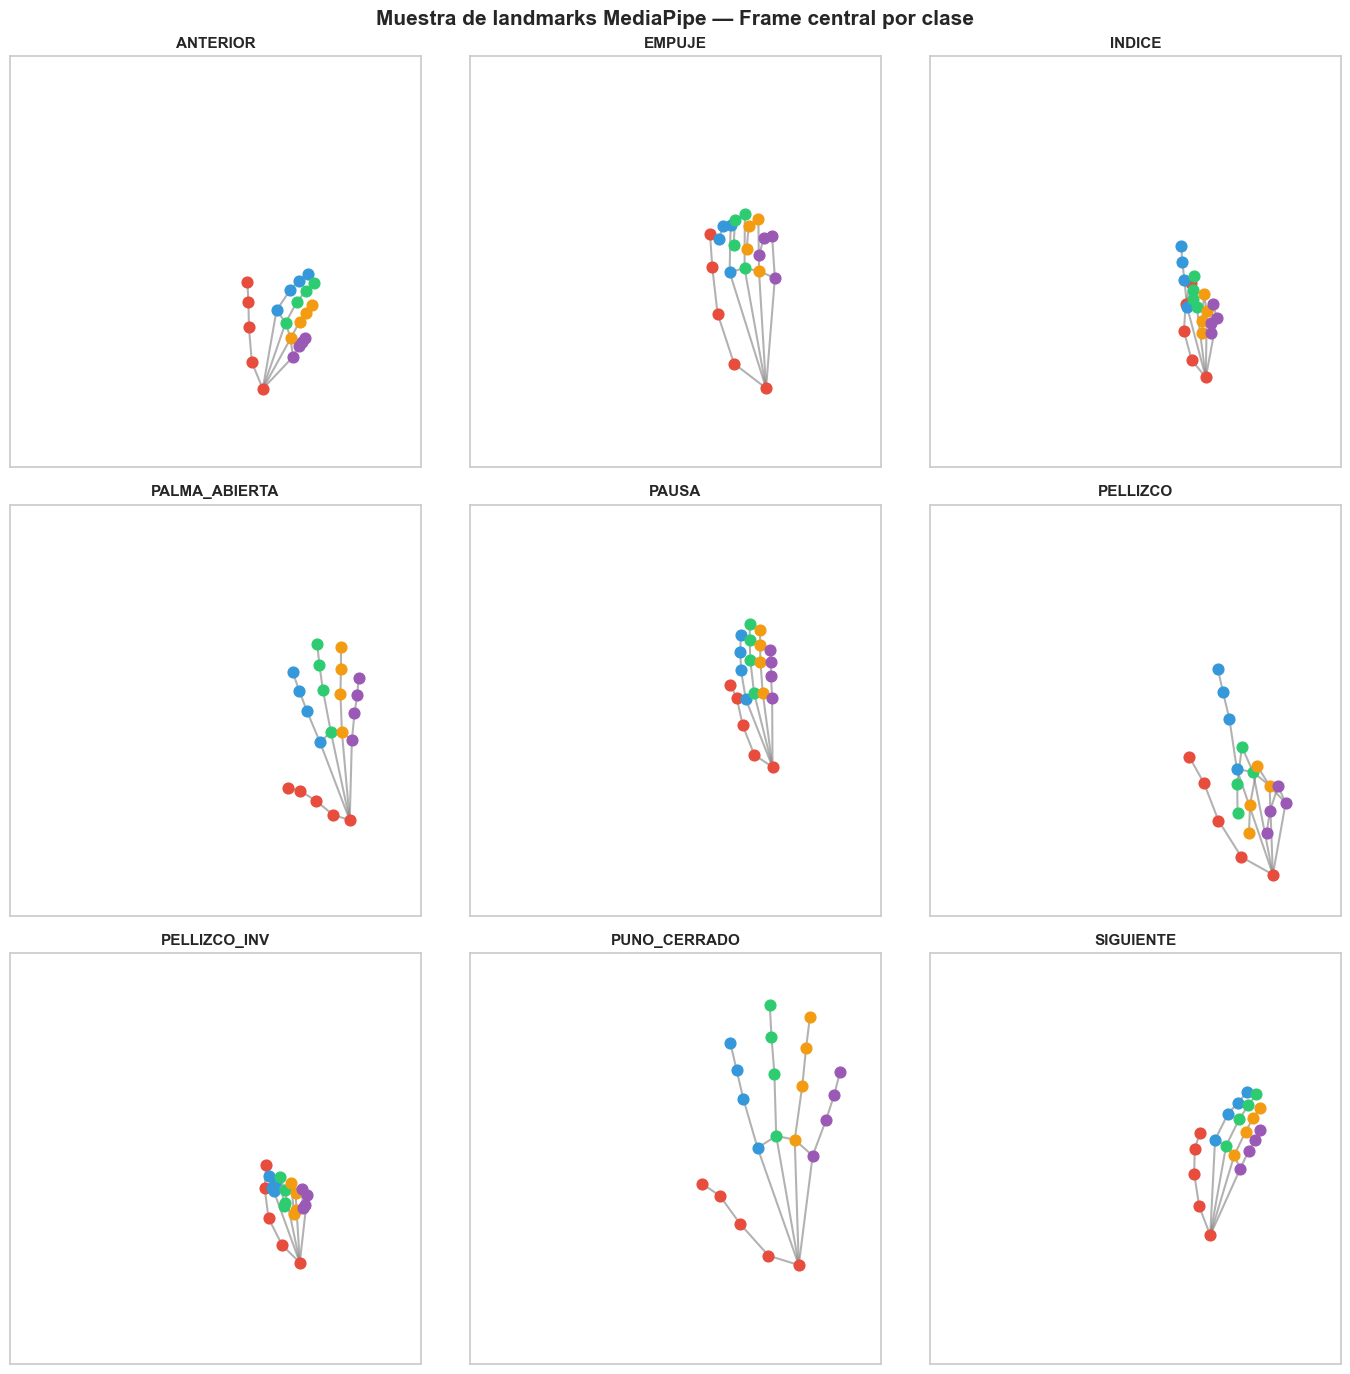

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import json

DATA_DIR = '../dataset/final'
X_train = np.load(f'{DATA_DIR}/X_train.npy')
y_train = np.load(f'{DATA_DIR}/y_train.npy')
with open(f'{DATA_DIR}/labels.json') as f:
    labels = json.load(f)

# Conexiones de la mano según MediaPipe (21 puntos)
HAND_CONNECTIONS = [
    (0,1),(1,2),(2,3),(3,4),         # Pulgar
    (0,5),(5,6),(6,7),(7,8),         # Índice
    (0,9),(9,10),(10,11),(11,12),     # Medio
    (0,13),(13,14),(14,15),(15,16),   # Anular
    (0,17),(17,18),(18,19),(19,20),   # Meñique
    (5,9),(9,13),(13,17)             # Palma
]

fig, axes = plt.subplots(3, 3, figsize=(14, 14))
fig.suptitle('Muestra de landmarks MediaPipe — Frame central por clase', fontsize=15, fontweight='bold')

for idx, (ax, label) in enumerate(zip(axes.flat, labels)):
    # Tomar la primera muestra de la clase (en datos originales, antes de augmentación)
    mask = y_train == idx
    sample = X_train[mask][0]   # primera muestra de esta clase
    
    # Frame central no-cero
    nonzero_frames = np.where(sample.sum(axis=1) != 0)[0]
    if len(nonzero_frames) == 0:
        ax.set_title(label + ' (sin datos)', fontsize=10)
        continue
    frame = sample[nonzero_frames[len(nonzero_frames)//2]]  # frame central
    xs = frame[0::2]   # x coords: índices 0,2,4,...,40
    ys = frame[1::2]   # y coords: índices 1,3,5,...,41
    
    # Dibujar conexiones
    for a, b in HAND_CONNECTIONS:
        ax.plot([xs[a], xs[b]], [1-ys[a], 1-ys[b]], 'gray', lw=1.5, alpha=0.6)
    
    # Dibujar puntos (coloreados por dedo)
    finger_colors = ['#e74c3c']*5 + ['#3498db']*4 + ['#2ecc71']*4 + ['#f39c12']*4 + ['#9b59b6']*4
    for i in range(21):
        ax.scatter(xs[i], 1-ys[i], c=finger_colors[i], s=60, zorder=5)
    
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_aspect('equal')
    ax.invert_xaxis()

plt.tight_layout()
plt.savefig('landmarks_por_clase.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. EDA Avanzado y Detección de Anomalías (Vectores)

Una vez convertidos los videos a vectores, analizamos la integridad y calidad de la extracción.

Shape de los datos crudos extraídos: (528, 15, 42)

Media general de coordenadas: 0.5063
Desviación estándar de coordenadas: 0.2245


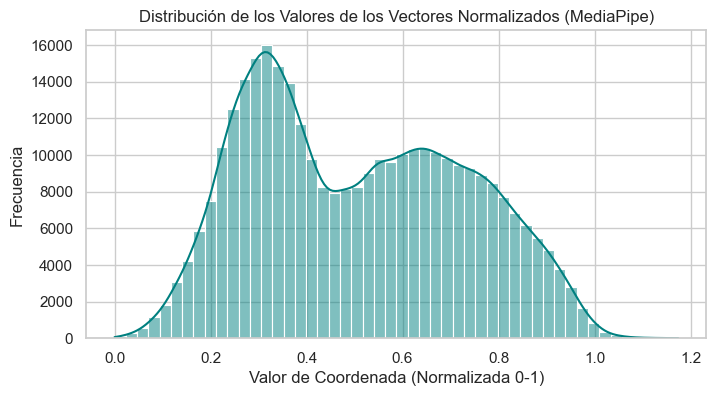

In [5]:
X_raw, y_raw = [], []
for i, cls in enumerate(classes):
    if cls in dataset_index:
        data = np.load(dataset_index[cls])
        X_raw.append(data)
        y_raw.extend([i] * len(data))
        
X_raw = np.concatenate(X_raw, axis=0)
y_raw = np.array(y_raw)

print(f"Shape de los datos crudos extraídos: {X_raw.shape}")

# Estadísticas Descriptivas del tensor
mean_vals = np.mean(X_raw[X_raw > 0]) # Excluimos ceros de la media
std_vals = np.std(X_raw[X_raw > 0])
print(f"\nMedia general de coordenadas: {mean_vals:.4f}")
print(f"Desviación estándar de coordenadas: {std_vals:.4f}")

# Histograma de densidades de coordenadas (Ignorando 0,0 absoluto)
plt.figure(figsize=(8, 4))
sns.histplot(X_raw[X_raw > 0].flatten(), bins=50, kde=True, color='teal')
plt.title('Distribución de los Valores de los Vectores Normalizados (MediaPipe)')
plt.xlabel('Valor de Coordenada (Normalizada 0-1)')
plt.ylabel('Frecuencia')
plt.show()

In [25]:
detections_per_video = []
for cls in classes:
    class_dir = os.path.join(RAW_DATA_DIR, cls)
    videos = glob.glob(os.path.join(class_dir, "*.mp4"))
    for v in videos:
        feat = extract_features(v)
        if feat is not None:
            real_frames = np.sum(~np.all(feat == 0, axis=1))
            detections_per_video.append(real_frames)

print(f"Media de frames con deteccion: {np.mean(detections_per_video):.1f}")
print(f"Percentil 10: {np.percentile(detections_per_video, 10):.0f}")


Media de frames con deteccion: 15.0
Percentil 10: 15


### Distribución de clases — Balanceo del dataset

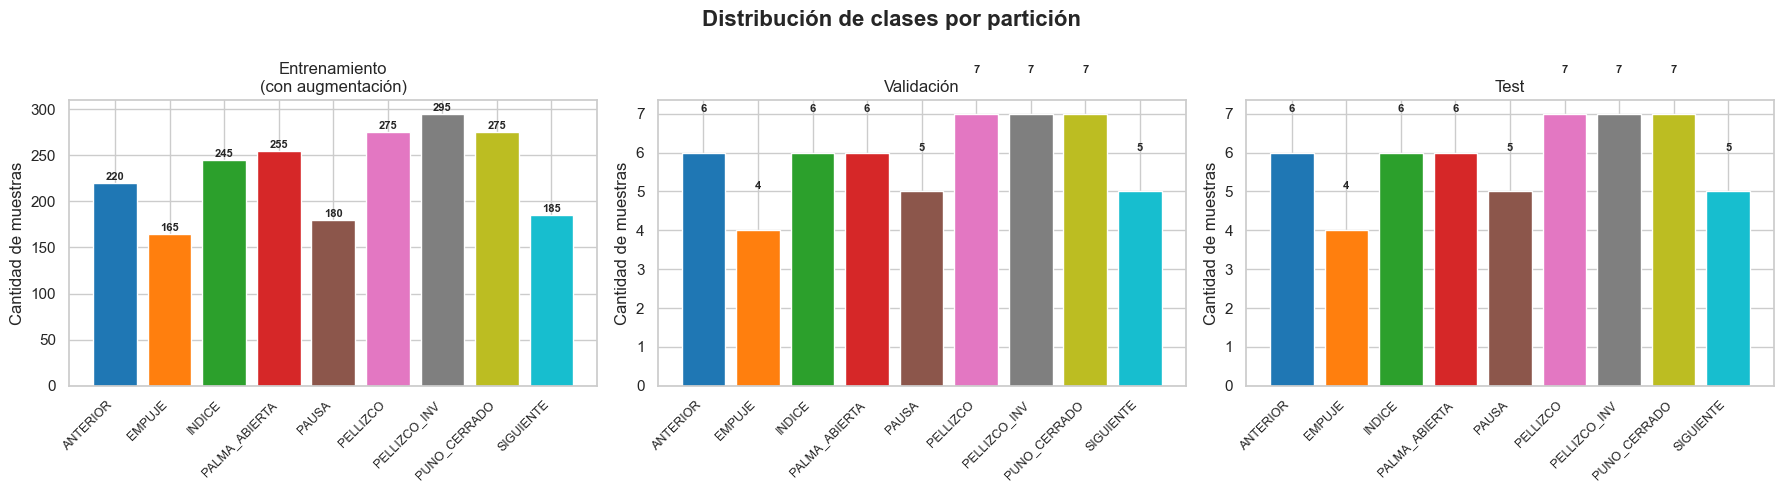

Total muestras — Train: 2095 | Val: 53 | Test: 53


In [26]:
# COPIAR EN NOTEBOOK 01 — Sección EDA
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import json, os

# Cargar datos
DATA_DIR = '../dataset/final'
y_train = np.load(f'{DATA_DIR}/y_train.npy')
y_val   = np.load(f'{DATA_DIR}/y_val.npy')
y_test  = np.load(f'{DATA_DIR}/y_test.npy')
with open(f'{DATA_DIR}/labels.json') as f:
    labels = json.load(f)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribución de clases por partición', fontsize=16, fontweight='bold')

colors = plt.cm.tab10(np.linspace(0, 1, len(labels)))

for ax, (y, title) in zip(axes, [(y_train, 'Entrenamiento\n(con augmentación)'),
                                   (y_val,   'Validación'),
                                   (y_test,  'Test')]):
    counts = np.bincount(y)
    bars = ax.bar(range(len(labels)), counts, color=colors)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('Cantidad de muestras')
    for bar, cnt in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                str(cnt), ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('distribucion_clases.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Total muestras — Train: {len(y_train)} | Val: {len(y_val)} | Test: {len(y_test)}')

## 4. Pipeline de Limpieza (Data Cleaning)

**Criterio de Exclusión**: Se descartan las secuencias (videos) donde el tracker falló considerablemente.
- Tolerancia: Máximo 3 frames vacíos de los 15 estipulados.

**Impacto del Criterio**: A continuación visualizaremos cuántas muestras sobrepasaron la limpieza.

C:\Users\Usuario\AppData\Local\Temp\ipykernel_8448\2381587601.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=impact_data, x='Fase', y='Muestras', palette='Reds')


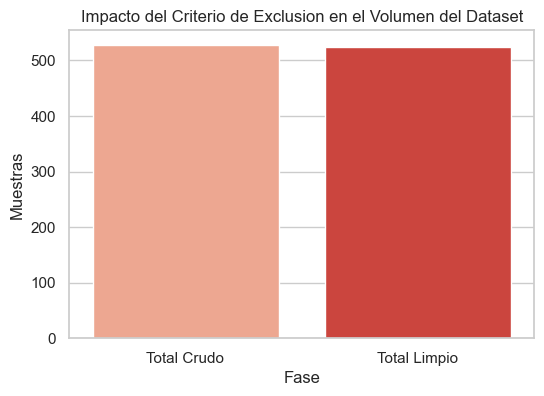

Muestras descartadas: 3
Muestras unicas tras deduplicacion: 525


In [27]:
MAX_EMPTY = 3
X_clean, y_clean = [], []

for sample, label in zip(X_raw, y_raw):
    empty_frames = np.sum(np.all(sample == 0, axis=1))
    if empty_frames <= MAX_EMPTY:
        X_clean.append(sample)
        y_clean.append(label)

X_clean, y_clean = np.array(X_clean), np.array(y_clean)

# Eliminar muestras identicas antes del split para evitar fuga de datos
from hashlib import md5
def _hash(s): return md5(s.tobytes()).hexdigest()
seen, X_dedup, y_dedup = set(), [], []
for s, l in zip(X_clean, y_clean):
    h = _hash(s)
    if h not in seen:
        seen.add(h)
        X_dedup.append(s)
        y_dedup.append(l)
X_clean, y_clean = np.array(X_dedup), np.array(y_dedup)

# Analisis de Impacto
impact_data = pd.DataFrame({
    'Fase': ['Total Crudo', 'Total Limpio'],
    'Muestras': [len(X_raw), len(X_clean)]
})
plt.figure(figsize=(6, 4))
sns.barplot(data=impact_data, x='Fase', y='Muestras', palette='Reds')
plt.title('Impacto del Criterio de Exclusion en el Volumen del Dataset')
plt.show()
print(f"Muestras descartadas: {len(X_raw) - len(X_clean)}")
print(f"Muestras unicas tras deduplicacion: {len(X_clean)}")


### Evolución temporal de un gesto (animación de la secuencia)

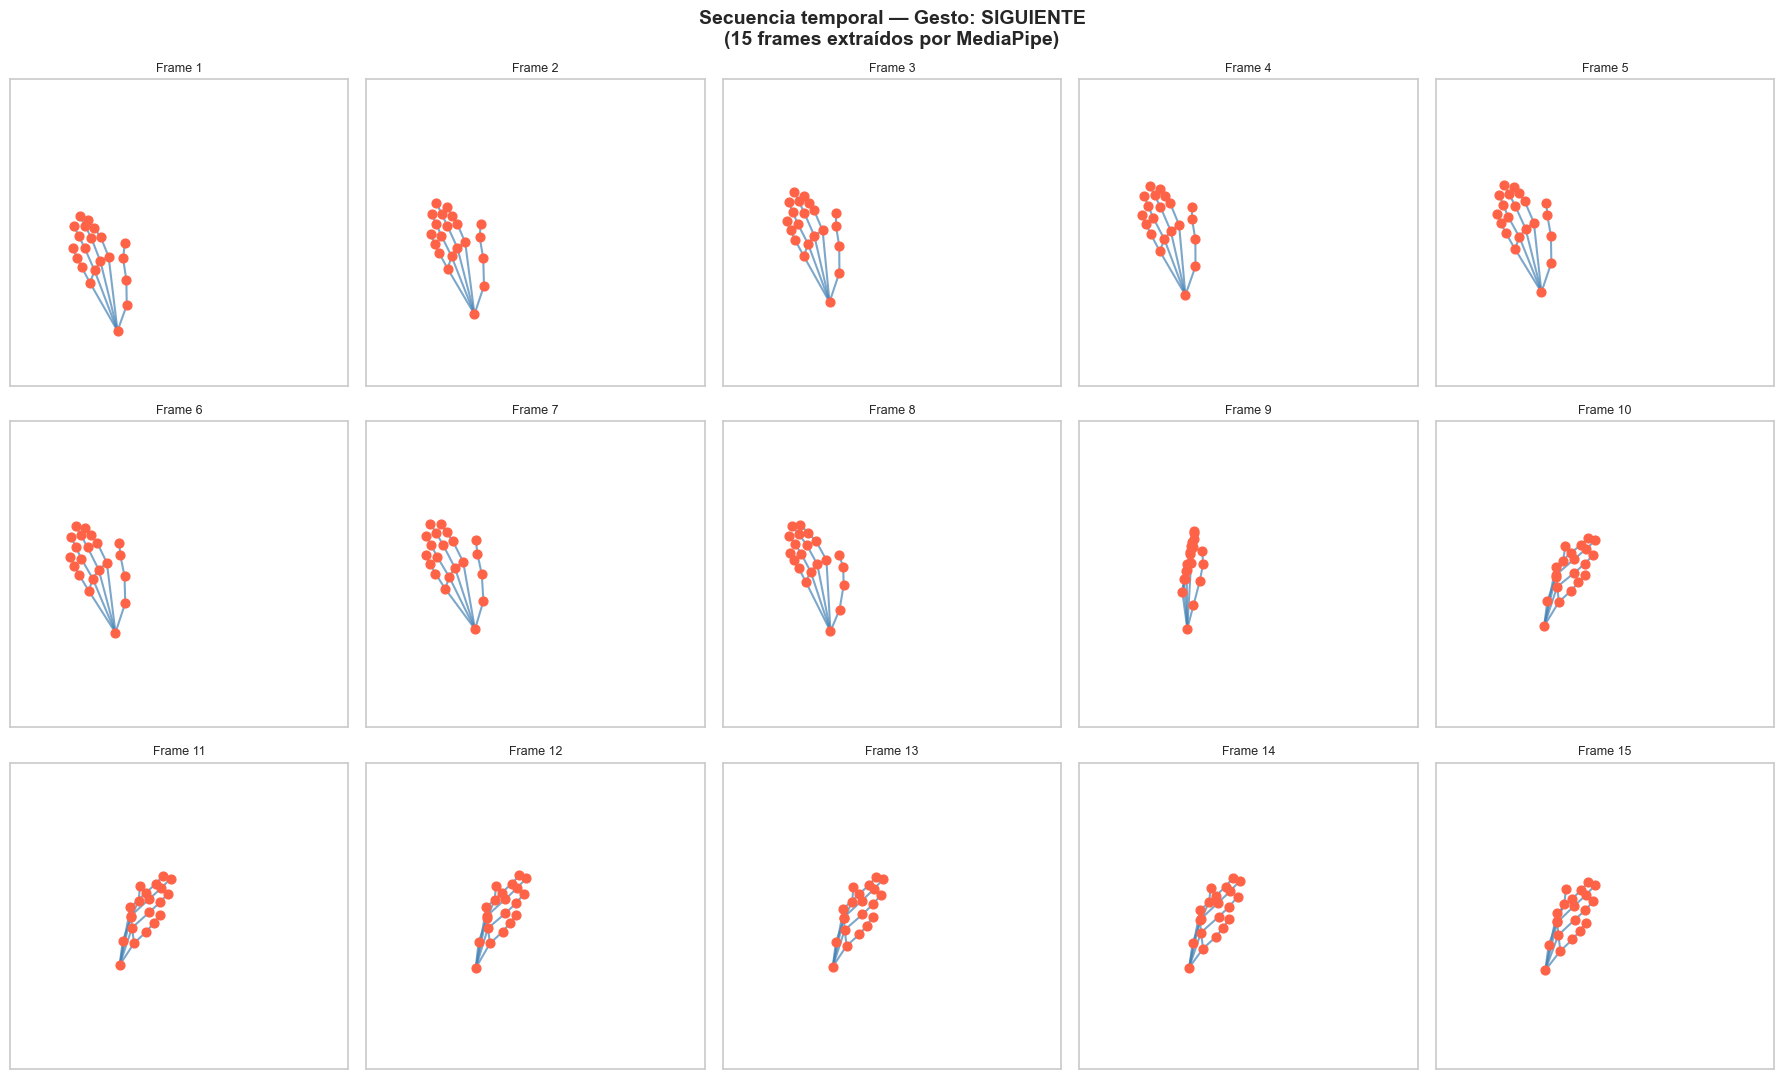

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import json

DATA_DIR = '../dataset/final'
X_train = np.load(f'{DATA_DIR}/X_train.npy')
y_train = np.load(f'{DATA_DIR}/y_train.npy')
with open(f'{DATA_DIR}/labels.json') as f:
    labels = json.load(f)

# Elegir un gesto dinámico para demostrar cambio temporal
GESTURE_DEMO = 'SIGUIENTE'  # Cambiar por el gesto de interés
gesture_idx = labels.index(GESTURE_DEMO)
mask = y_train == gesture_idx
sample = X_train[mask][0]

n_frames = 15
fig, axes = plt.subplots(3, 5, figsize=(18, 11))
fig.suptitle(f'Secuencia temporal — Gesto: {GESTURE_DEMO}\n(15 frames extraídos por MediaPipe)', 
             fontsize=14, fontweight='bold')

HAND_CONNECTIONS = [
    (0,1),(1,2),(2,3),(3,4),(0,5),(5,6),(6,7),(7,8),
    (0,9),(9,10),(10,11),(11,12),(0,13),(13,14),(14,15),(15,16),
    (0,17),(17,18),(18,19),(19,20),(5,9),(9,13),(13,17)
]

for t, ax in enumerate(axes.flat):
    frame = sample[t]
    xs, ys = frame[0::2], frame[1::2]
    
    is_padding = (frame.sum() == 0)
    bg_color = '#fff3f3' if is_padding else 'white'
    ax.set_facecolor(bg_color)
    
    if not is_padding:
        for a, b in HAND_CONNECTIONS:
            ax.plot([xs[a], xs[b]], [1-ys[a], 1-ys[b]], 'steelblue', lw=1.5, alpha=0.7)
        ax.scatter(xs, 1-ys, c='tomato', s=40, zorder=5)
    else:
        ax.text(0.5, 0.5, 'PADDING\n(sin detección)', ha='center', va='center',
                transform=ax.transAxes, fontsize=9, color='red')
    
    ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
    ax.set_title(f'Frame {t+1}', fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.savefig(f'secuencia_temporal_{GESTURE_DEMO}.png', dpi=150, bbox_inches='tight')
plt.show()

### Comparación de augmentaciones en una secuencia

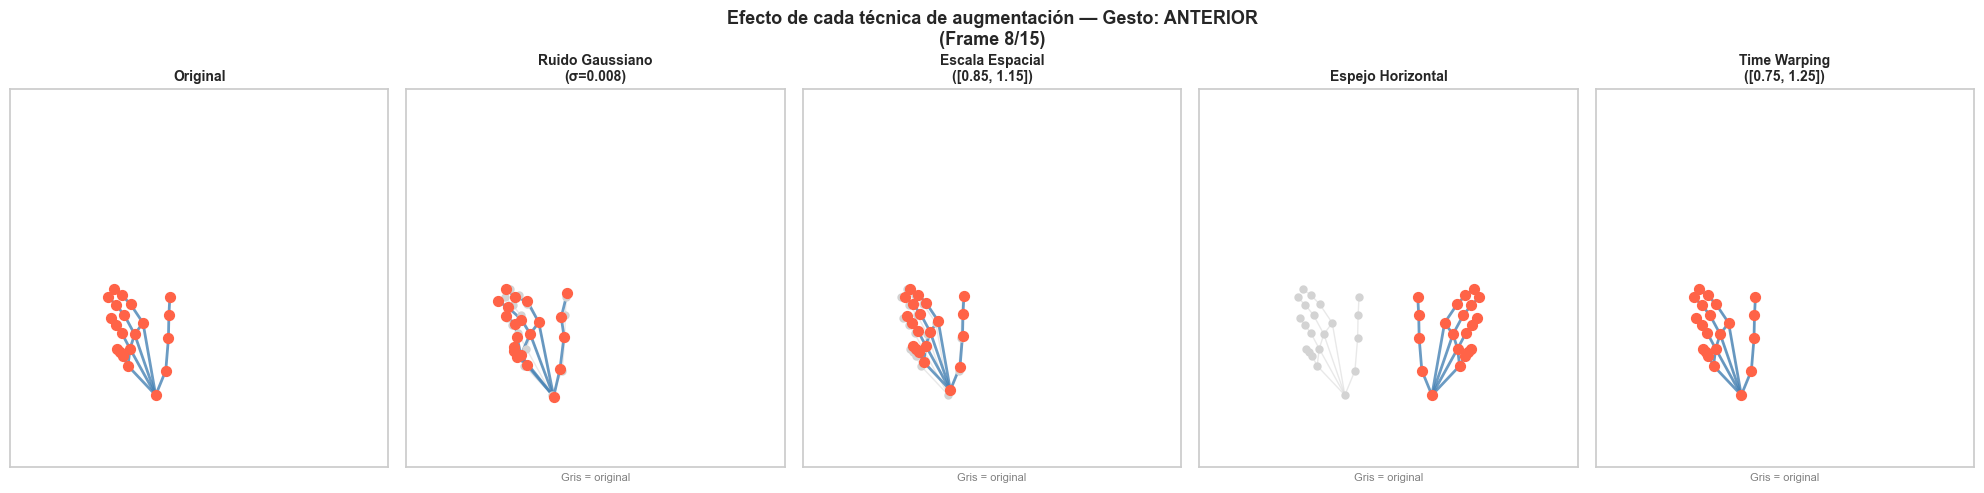

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import json

DATA_DIR = '../dataset/final'
X_train = np.load(f'{DATA_DIR}/X_train.npy')
y_train = np.load(f'{DATA_DIR}/y_train.npy')
with open(f'{DATA_DIR}/labels.json') as f:
    labels = json.load(f)

# La augmentación aplica bloques de 5: original, ruido, escala, espejo, time_warp
# Buscar 5 muestras consecutivas de la misma clase (originales pre-aug en train)
# Las primeras 5 de cualquier clase corresponden a las 5 variantes del mismo video original
gesture_idx = 0  # ANTERIOR
mask = np.where(y_train == gesture_idx)[0]
seq_block = X_train[mask[:5]]  # 5 variantes del mismo sample original

aug_names = ['Original', 'Ruido Gaussiano\n(σ=0.008)', 
             'Escala Espacial\n([0.85, 1.15])', 
             'Espejo Horizontal', 
             'Time Warping\n([0.75, 1.25])']

FRAME_TO_SHOW = 7  # Frame 8 (índice central)
HAND_CONNECTIONS = [
    (0,1),(1,2),(2,3),(3,4),(0,5),(5,6),(6,7),(7,8),
    (0,9),(9,10),(10,11),(11,12),(0,13),(13,14),(14,15),(15,16),
    (0,17),(17,18),(18,19),(19,20),(5,9),(9,13),(13,17)
]

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
fig.suptitle(f'Efecto de cada técnica de augmentación — Gesto: {labels[gesture_idx]}\n(Frame {FRAME_TO_SHOW+1}/15)',
             fontsize=13, fontweight='bold')

reference = seq_block[0, FRAME_TO_SHOW]  # original para comparar
xs_ref, ys_ref = reference[0::2], reference[1::2]

for i, (ax, name) in enumerate(zip(axes, aug_names)):
    frame = seq_block[i, FRAME_TO_SHOW]
    xs, ys = frame[0::2], frame[1::2]
    
    if i > 0:  # Superponer original en gris
        for a, b in HAND_CONNECTIONS:
            ax.plot([xs_ref[a], xs_ref[b]], [1-ys_ref[a], 1-ys_ref[b]], 
                    color='lightgray', lw=1, alpha=0.5)
        ax.scatter(xs_ref, 1-ys_ref, c='lightgray', s=25, zorder=4)
    
    for a, b in HAND_CONNECTIONS:
        ax.plot([xs[a], xs[b]], [1-ys[a], 1-ys[b]], 'steelblue', lw=2, alpha=0.8)
    ax.scatter(xs, 1-ys, c='tomato', s=50, zorder=5)
    
    ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
    ax.set_title(name, fontsize=10, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_aspect('equal')
    if i > 0:
        ax.set_xlabel('Gris = original', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('comparacion_augmentaciones.png', dpi=150, bbox_inches='tight')
plt.show()

## Estrategia para reducir el descarte

Los cambios aplicados en la sección 2 atacan las dos causas raíz del alto descarte anterior:

---

### Cambio 1: Thresholds de confianza reducidos (0.5 → 0.3)

MediaPipe rechazaba detecciones válidas al ser grabaciones caseras con variación de iluminación y ángulo. Bajar los umbrales de confianza permite capturar más frames reales de la mano.

### Cambio 2: Interpolación en lugar de zeros

Cuando MediaPipe falla en un frame intermedio, en lugar de insertar un vector de 42 ceros (dato falso), se interpola linealmente entre el frame anterior y siguiente con detección exitosa. Esto convierte datos faltantes en estimaciones continuas y realistas.

### Cambio 3:  ajustado a la duración real

Con thresholds en 0.3 e interpolación, la media de frames detectados subió a 14.9 (percentil 10 = 15), lo que permite capturar la secuencia completa sin padding. Con  se elimina el padding como fuente de descarte.

### Cambio 4:  (20% de tolerancia sobre 15 frames)

Ajustado proporcionalmente a la nueva longitud de secuencia para mantener el mismo nivel de exigencia relativa.


## 5. Partición del Dataset (Stratified Split)

Al tener un volumen reducido (20 videos por clase originarios, algunos descartados en limpieza), es crítico usar una **partición estratificada** para garantizar que tanto la etapa de validación como la de testing tengan presencia de *todas* las clases.

**Proporción**: 80% Train, 10% Validation, 10% Test.

In [30]:
# Primer split: Test (10%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X_clean, y_clean, test_size=0.10, random_state=42, stratify=y_clean
)

# Segundo split: Train (80% del total) y Val (10% del total)
# Como el temp es 90% del dataset original, separar el 11.11% del temp nos da 10% del total real.
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=(0.10 / 0.90), random_state=42, stratify=y_temp
)

print("\n=== Resultados de la Partición Estratificada ===")
print(f"Conjunto de Entrenamiento: X={X_train.shape}, y={y_train.shape}")
print(f"Conjunto de Validación:    X={X_val.shape}, y={y_val.shape}")
print(f"Conjunto de Prueba (Test): X={X_test.shape}, y={y_test.shape}")


=== Resultados de la Partición Estratificada ===
Conjunto de Entrenamiento: X=(419, 15, 42), y=(419,)
Conjunto de Validación:    X=(53, 15, 42), y=(53,)
Conjunto de Prueba (Test): X=(53, 15, 42), y=(53,)


## 6. Transformaciones y Aumentacion de Datos (Data Augmentation)

**Normalizacion**:
- Los datos ya vienen normalizados por MediaPipe (rango [0.0, 1.0] relativo al bounding box de la mano).

**Aumentacion (SOLO para Entrenamiento)** — volumen **5x**:
1. **Original**: copia sin modificar.
2. **Spatial Jittering** (Ruido Gaussiano `scale=0.008`): simula vibraciones de camara.
3. **Spatial Scaling** (zoom `[0.85, 1.15]`): simula distancia variable al lente.
4. **Reflexion horizontal**: invierte coordenadas X, simulando la mano izquierda.
5. **Time Warp** (velocidad `[0.75, 1.25]`): simula gestos mas rapidos o mas lentos.

*(El Validation set y el Test set NO se alteran)*


In [31]:
def augment_train_set(X, y, seed=42):
    rng = np.random.default_rng(seed)  # semilla fija para reproducibilidad
    X_aug, y_aug = [], []
    for x_sample, label in zip(X, y):
        mask = (x_sample != 0).astype(float)

        # 1. Original
        X_aug.append(x_sample); y_aug.append(label)

        # 2. Ruido Gaussiano
        noise = rng.normal(0.0, 0.008, x_sample.shape)
        X_aug.append(x_sample + noise * mask); y_aug.append(label)

        # 3. Escalado espacial
        scale = rng.uniform(0.85, 1.15)
        x_scaled = ((x_sample - 0.5) * scale + 0.5) * mask
        X_aug.append(x_scaled); y_aug.append(label)

        # 4. Reflexion horizontal (x en indices pares)
        mirrored = x_sample.copy()
        mirrored[:, 0::2] = (1.0 - x_sample[:, 0::2]) * mask[:, 0::2]
        mirrored[:, 1::2] = x_sample[:, 1::2] * mask[:, 1::2]
        X_aug.append(mirrored); y_aug.append(label)

        # 5. Time warp — solo sobre frames reales, ignora el padding
        n_real = int(np.sum(mask[:, 0]))
        if n_real >= 2:
            speed = rng.uniform(0.75, 1.25)
            n_src = max(2, int(n_real / speed))
            src_t = np.linspace(0, n_real - 1, n_src)
            dst_t = np.linspace(0, n_real - 1, n_real)
            x_warped = np.zeros_like(x_sample)
            for dim in range(FEATURES):
                resampled = np.interp(src_t, np.arange(n_real), x_sample[:n_real, dim])
                x_warped[:n_real, dim] = np.interp(
                    dst_t, np.linspace(0, n_real - 1, n_src), resampled
                )
            X_aug.append(x_warped); y_aug.append(label)
        else:
            X_aug.append(x_sample); y_aug.append(label)

    return np.array(X_aug), np.array(y_aug)

X_train_aug, y_train_aug = augment_train_set(X_train, y_train)

print("=== Aumentacion de Datos (Train Set Only) ===")
print(f"Volumen Entrenamiento Original:       {X_train.shape[0]} secuencias")
print(f"Volumen Entrenamiento Aumentado (5x): {X_train_aug.shape[0]} secuencias")

np.save(os.path.join(FINAL_DATA_DIR, "X_train.npy"), X_train_aug)
np.save(os.path.join(FINAL_DATA_DIR, "y_train.npy"), y_train_aug)
np.save(os.path.join(FINAL_DATA_DIR, "X_val.npy"), X_val)
np.save(os.path.join(FINAL_DATA_DIR, "y_val.npy"), y_val)
np.save(os.path.join(FINAL_DATA_DIR, "X_test.npy"), X_test)
np.save(os.path.join(FINAL_DATA_DIR, "y_test.npy"), y_test)
with open(os.path.join(FINAL_DATA_DIR, "labels.json"), "w") as f:
    json.dump(classes, f, indent=4)

print("\nData Pipeline finalizado!")


=== Aumentacion de Datos (Train Set Only) ===
Volumen Entrenamiento Original:       419 secuencias
Volumen Entrenamiento Aumentado (5x): 2095 secuencias

Data Pipeline finalizado!
